# Semana 2: Análisis Exploratorio y Feature Engineering
## Notebook de Ejercicios (NB2) – EDA sobre Dataset Real: Titanic

**Propósito:** Aplicar técnicas de análisis exploratorio y feature engineering sobre un dataset real. Utilizaremos el dataset Titanic (disponible en Seaborn) para practicar estadísticas descriptivas, visualizaciones, detección de nulos, correlaciones, creación de nuevas características y construcción de un pipeline de preprocesamiento.

**Docente:** Carlos César Sánchez Coronel

**Objetivo de negocio:** Predecir la supervivencia de los pasajeros del Titanic. En este notebook nos enfocaremos en la preparación de datos, dejando el modelado para sesiones posteriores.

---

## 0. Configuración Inicial

Importamos las librerías necesarias y cargamos el dataset directamente desde Seaborn.

In [1]:
# Importamos librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Módulos de scikit-learn para preprocesamiento y pipelines
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, OrdinalEncoder, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Configuración de visualización
%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


---
## 1. Carga del Dataset

Cargamos el dataset Titanic directamente desde Seaborn. Este dataset ya está limpio y listo para usar, pero contiene valores nulos y variables categóricas que necesitan tratamiento.

In [2]:
# Cargar dataset Titanic desde seaborn
df = sns.load_dataset('titanic')

print(f"Dimensiones del dataset: {df.shape}")
print("\nPrimeras 5 filas:")
df.head()

Dimensiones del dataset: (891, 15)

Primeras 5 filas:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
# Información general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


### Descripción de las variables:

- **survived**: 0 = No, 1 = Sí (variable objetivo)
- **pclass**: Clase del pasajero (1 = 1ª, 2 = 2ª, 3 = 3ª)
- **sex**: Sexo
- **age**: Edad
- **sibsp**: Número de hermanos/cónyuges a bordo
- **parch**: Número de padres/hijos a bordo
- **fare**: Tarifa del pasaje
- **embarked**: Puerto de embarque (C = Cherburgo, Q = Queenstown, S = Southampton)
- **class**: Clase (versión textual de pclass)
- **who**: Hombre, mujer o niño
- **adult_male**: Indicador de hombre adulto
- **deck**: Cubierta (letra)
- **embark_town**: Ciudad de embarque (textual)
- **alive**: 'yes' o 'no'
- **alone**: Si viajaba solo o no

---
## 2. Análisis Exploratorio de Datos (EDA) Completo

Realizaremos un análisis detallado que incluye:
- Estadísticas descriptivas
- Detección de valores nulos
- Análisis de correlaciones
- Visualizaciones univariadas y multivariadas

### 2.1. Estadísticas Descriptivas

Analizamos las variables numéricas y categóricas por separado.

In [4]:
# Variables numéricas
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
# Variables categóricas
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- sex ---
sex
male      577
female    314
Name: count, dtype: int64

--- embarked ---
embarked
S    644
C    168
Q     77
Name: count, dtype: int64

--- class ---
class
Third     491
First     216
Second    184
Name: count, dtype: int64

--- who ---
who
man      537
woman    271
child     83
Name: count, dtype: int64

--- deck ---
deck
C    59
B    47
D    33
E    32
A    15
F    13
G     4
Name: count, dtype: int64

--- embark_town ---
embark_town
Southampton    644
Cherbourg      168
Queenstown      77
Name: count, dtype: int64

--- alive ---
alive
no     549
yes    342
Name: count, dtype: int64


### 2.2. Detección de Valores Nulos

Identificamos qué variables tienen nulos y en qué proporción.

In [6]:
# Porcentaje de nulos por columna
null_percentage = (df.isnull().sum() / len(df)) * 100
null_df = pd.DataFrame({'Variable': null_percentage.index, '% Nulos': null_percentage.values})
null_df.sort_values('% Nulos', ascending=False)

,Variable,% Nulos
11,deck,77.216611
3,age,19.865320
7,embarked,0.224467
12,embark_town,0.224467
2,sex,0.000000
1,pclass,0.000000
0,survived,0.000000
6,fare,0.000000
5,parch,0.000000
4,sibsp,0.000000


### 2.3. Visualizaciones Univariadas

Exploramos la distribución de las variables más importantes.

/tmp/ipykernel_502/1268436097.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['No', 'Sí'])


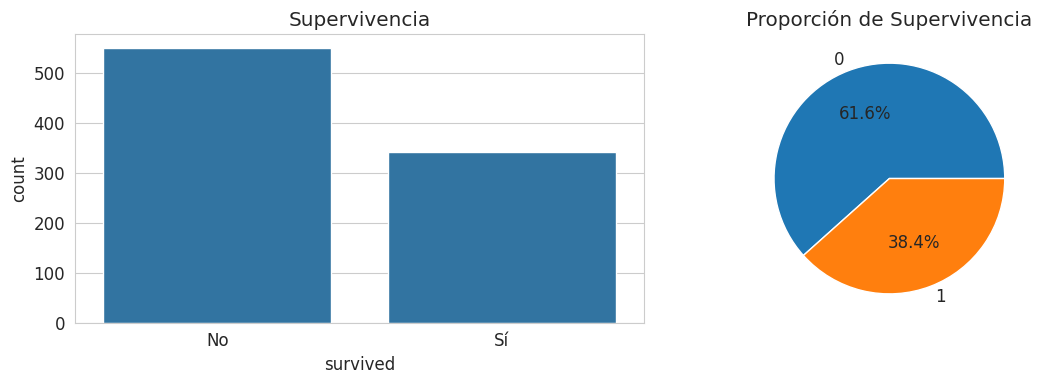

In [7]:
# Variable objetivo: survived
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df, x='survived', ax=axes[0])
axes[0].set_title('Supervivencia')
axes[0].set_xticklabels(['No', 'Sí'])

df['survived'].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[1])
axes[1].set_title('Proporción de Supervivencia')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

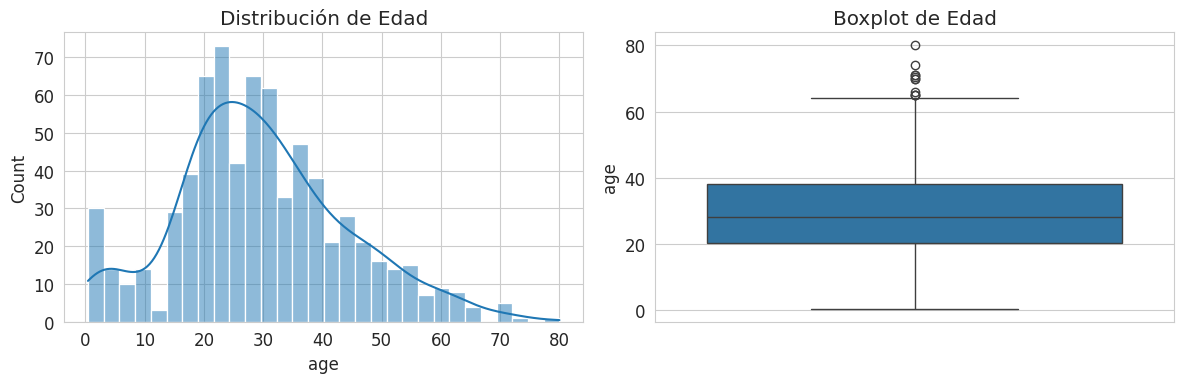

In [8]:
# Distribución de edad
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['age'].dropna(), kde=True, bins=30, ax=axes[0])
axes[0].set_title('Distribución de Edad')

sns.boxplot(y=df['age'].dropna(), ax=axes[1])
axes[1].set_title('Boxplot de Edad')

plt.tight_layout()
plt.show()

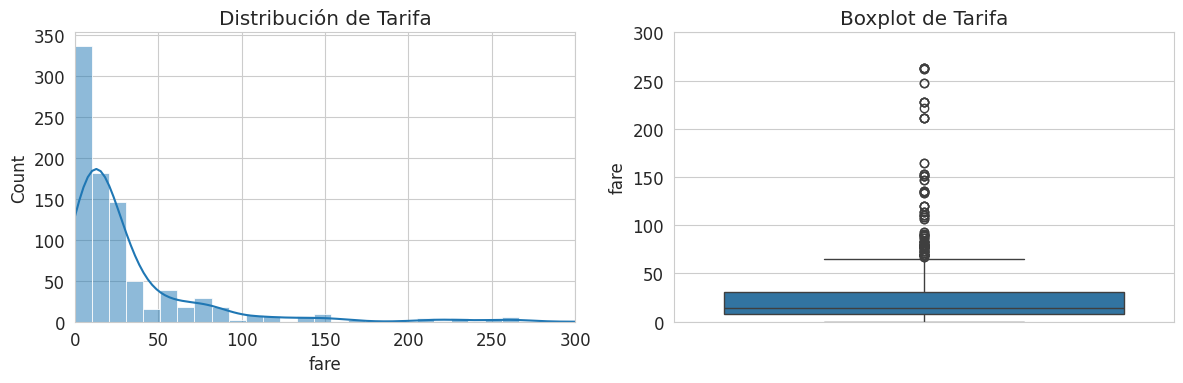

In [9]:
# Distribución de tarifa (fare)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['fare'], kde=True, bins=50, ax=axes[0])
axes[0].set_title('Distribución de Tarifa')
axes[0].set_xlim(0, 300)  # Limitamos para mejor visualización

sns.boxplot(y=df['fare'], ax=axes[1])
axes[1].set_title('Boxplot de Tarifa')
axes[1].set_ylim(0, 300)

plt.tight_layout()
plt.show()

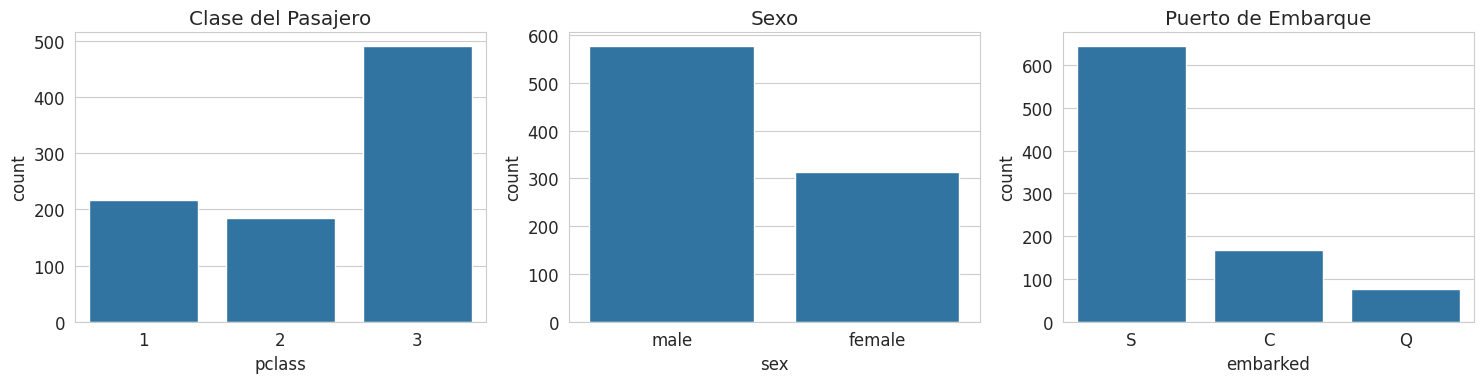

In [10]:
# Variables categóricas clave
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.countplot(data=df, x='pclass', ax=axes[0])
axes[0].set_title('Clase del Pasajero')

sns.countplot(data=df, x='sex', ax=axes[1])
axes[1].set_title('Sexo')

sns.countplot(data=df, x='embarked', ax=axes[2])
axes[2].set_title('Puerto de Embarque')

plt.tight_layout()
plt.show()

### 2.4. Visualizaciones Multivariadas

Exploramos relaciones entre variables y su impacto en la supervivencia.

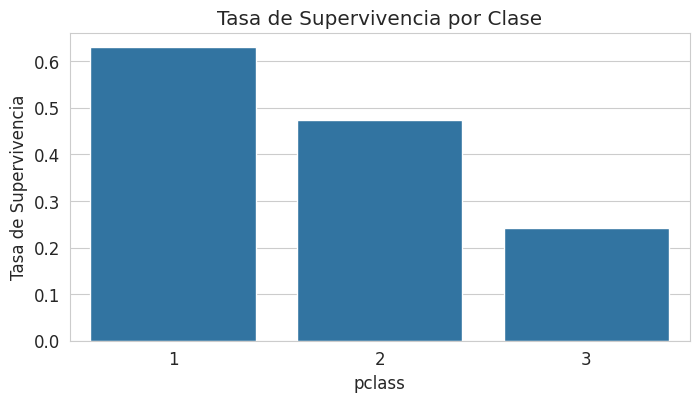

In [11]:
# Supervivencia por clase
plt.figure(figsize=(8, 4))
sns.barplot(data=df, x='pclass', y='survived', errorbar=None)
plt.title('Tasa de Supervivencia por Clase')
plt.ylabel('Tasa de Supervivencia')
plt.show()

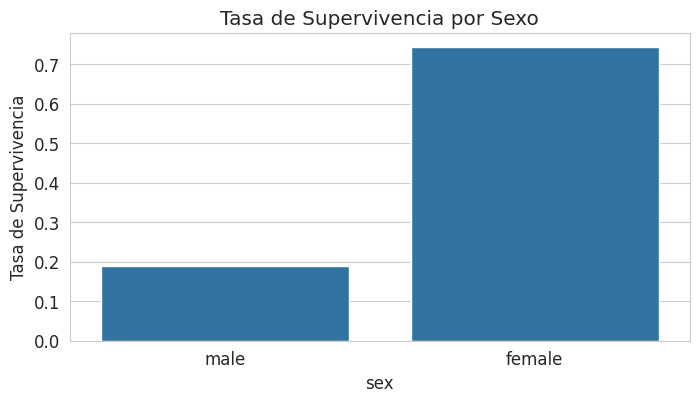

In [12]:
# Supervivencia por sexo
plt.figure(figsize=(8, 4))
sns.barplot(data=df, x='sex', y='survived', errorbar=None)
plt.title('Tasa de Supervivencia por Sexo')
plt.ylabel('Tasa de Supervivencia')
plt.show()

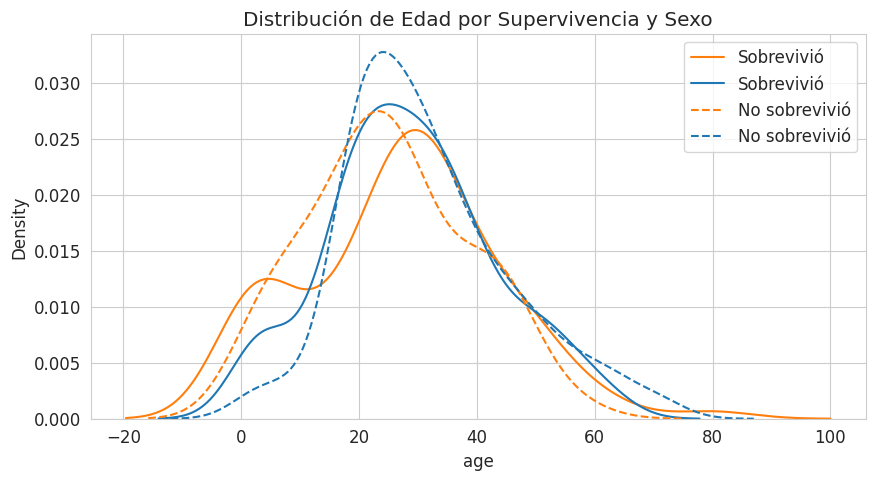

In [13]:
# Distribución de edad por supervivencia y sexo
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df[df['survived']==1], x='age', hue='sex', common_norm=False, label='Sobrevivió')
sns.kdeplot(data=df[df['survived']==0], x='age', hue='sex', common_norm=False, linestyle='--', label='No sobrevivió')
plt.title('Distribución de Edad por Supervivencia y Sexo')
plt.legend()
plt.show()

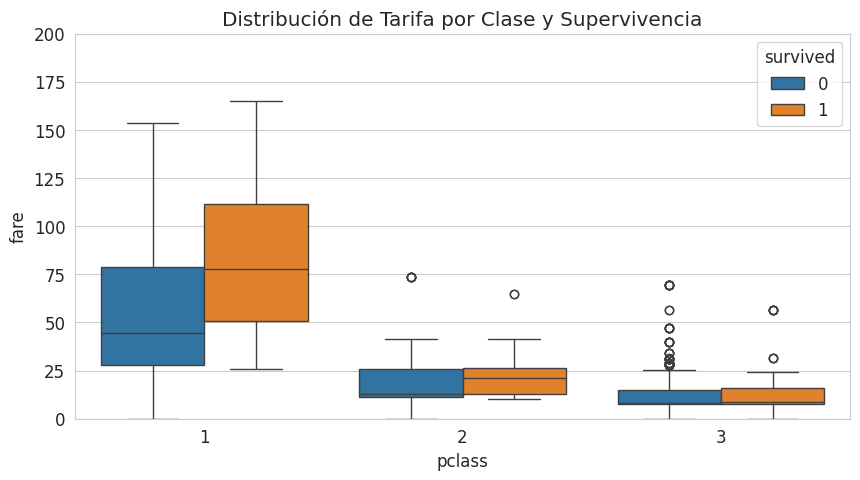

In [14]:
# Boxplot de tarifa por clase y supervivencia
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='pclass', y='fare', hue='survived')
plt.title('Distribución de Tarifa por Clase y Supervivencia')
plt.ylim(0, 200)
plt.show()

### 2.5. Análisis de Correlaciones

Calculamos la matriz de correlación para variables numéricas y visualizamos con un heatmap.

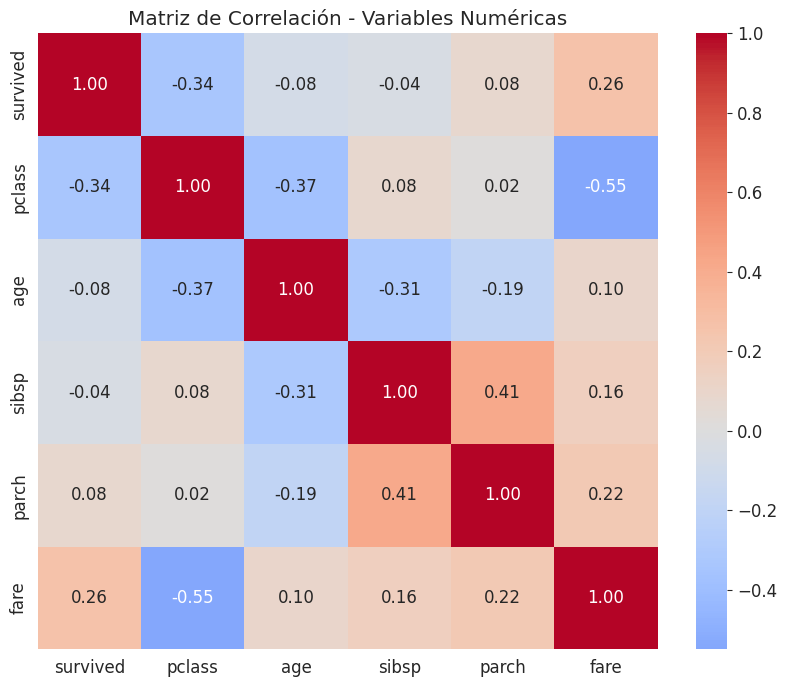

In [15]:
# Seleccionamos variables numéricas
numeric_df = df.select_dtypes(include=[np.number])

# Matriz de correlación
corr_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Matriz de Correlación - Variables Numéricas')
plt.show()

---
## 3. Feature Engineering

Creamos nuevas características que puedan ayudar a predecir la supervivencia. Justificamos cada una basándonos en el EDA realizado.

### 3.1. Tamaño de la Familia

Combinamos `sibsp` (hermanos/cónyuges) y `parch` (padres/hijos) para crear una variable que indique el tamaño total de la familia a bordo.

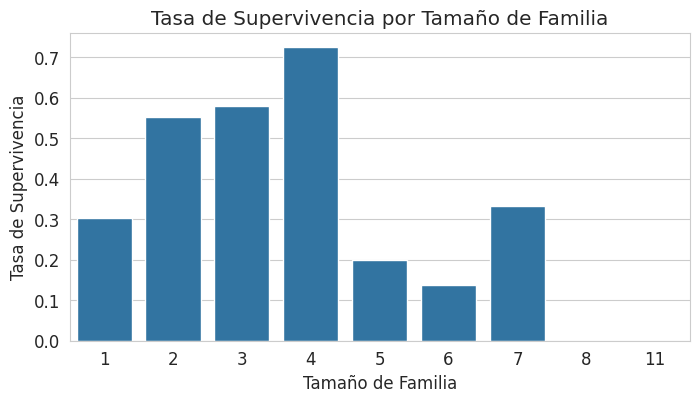

In [16]:
df['family_size'] = df['sibsp'] + df['parch'] + 1  # +1 incluye al propio pasajero

# Visualizamos la relación con supervivencia
plt.figure(figsize=(8, 4))
sns.barplot(data=df, x='family_size', y='survived', errorbar=None)
plt.title('Tasa de Supervivencia por Tamaño de Familia')
plt.xlabel('Tamaño de Familia')
plt.ylabel('Tasa de Supervivencia')
plt.show()

### 3.2. Indicador de Niño

Del EDA observamos que los niños (edad < 12) podrían tener mayor probabilidad de supervivencia. Creamos una variable binaria.

In [17]:
df['is_child'] = (df['age'] < 12).astype(int)

# Verificamos
print("Tasa de supervivencia para niños vs adultos:")
print(df.groupby('is_child')['survived'].mean())

Tasa de supervivencia para niños vs adultos:
is_child
0    0.368165
1    0.573529
Name: survived, dtype: float64


### 3.3. Tarifa por Persona

La tarifa total puede ser para toda la familia. Dividimos entre el tamaño familiar para estimar la tarifa individual.

/tmp/ipykernel_502/2263147836.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['No', 'Sí'])
/tmp/ipykernel_502/2263147836.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['No', 'Sí'])


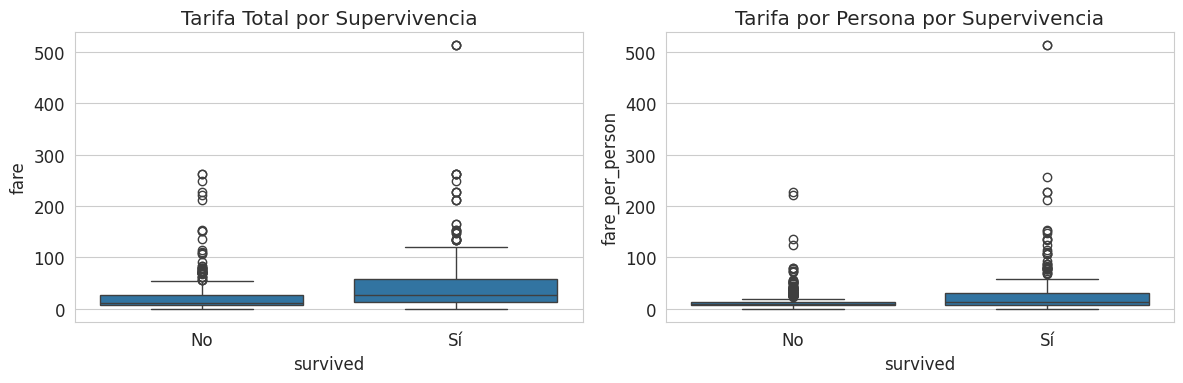

In [18]:
df['fare_per_person'] = df['fare'] / df['family_size']

# Comparación
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=df, x='survived', y='fare', ax=axes[0])
axes[0].set_title('Tarifa Total por Supervivencia')
axes[0].set_xticklabels(['No', 'Sí'])

sns.boxplot(data=df, x='survived', y='fare_per_person', ax=axes[1])
axes[1].set_title('Tarifa por Persona por Supervivencia')
axes[1].set_xticklabels(['No', 'Sí'])

plt.tight_layout()
plt.show()

---
## 4. Transformaciones para Normalizar Distribuciones

Algunas variables como 'fare' tienen distribuciones muy asimétricas. Aplicamos transformaciones para hacerlas más cercanas a la normal.

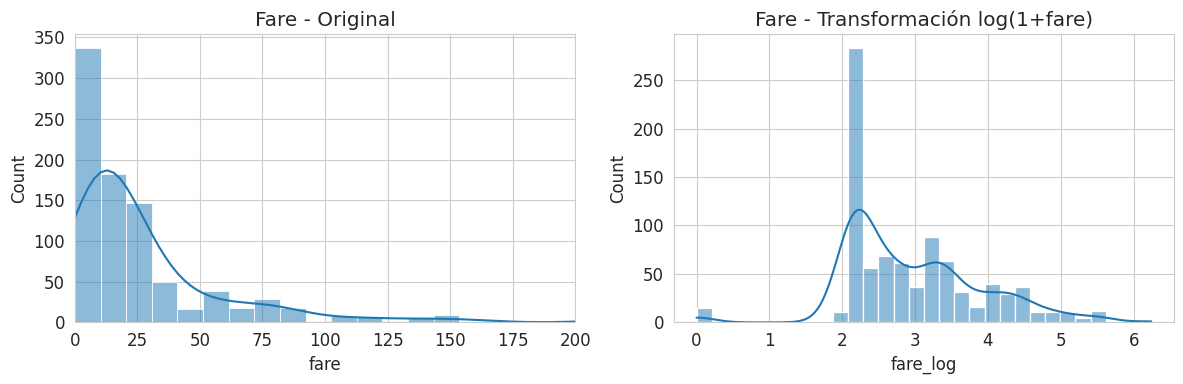

In [22]:
# Transformación logarítmica para fare (requiere valores positivos)
df['fare_log'] = np.log1p(df['fare'])  # log(1+fare) para evitar log(0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['fare'], kde=True, bins=50, ax=axes[0])
axes[0].set_title('Fare - Original')
axes[0].set_xlim(0, 200)

sns.histplot(df['fare_log'], kde=True, bins=30, ax=axes[1])
axes[1].set_title('Fare - Transformación log(1+fare)')

plt.tight_layout()
plt.show()

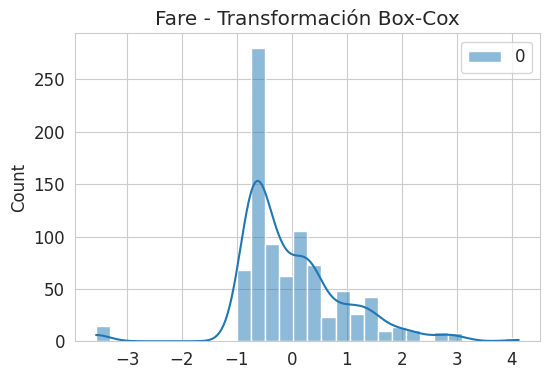

In [23]:
# Transformación Box-Cox para fare (requiere valores positivos)
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='box-cox')
fare_boxcox = pt.fit_transform(df[['fare']] + 1e-6)  # evitamos ceros exactos

plt.figure(figsize=(6, 4))
sns.histplot(fare_boxcox, kde=True, bins=30)
plt.title('Fare - Transformación Box-Cox')
plt.show()

---
## 5. Construcción de un Pipeline de Preprocesamiento

Construimos un pipeline completo que incluya todas las transformaciones necesarias para preparar los datos para el modelado. Esto nos permitirá aplicarlas de manera consistente en entrenamiento y prueba, evitando data leakage.

In [24]:
# Definimos las columnas por tipo
numeric_features = ['age', 'fare', 'sibsp', 'parch', 'family_size', 'fare_per_person']
categorical_nominal = ['sex', 'embarked'] # 'title' removed as 'name' column is missing
categorical_ordinal = ['pclass']  # pclass tiene orden (1,2,3)

# Pipeline para numéricas: imputar por mediana, escalar con StandardScaler
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline para nominales: imputar con 'missing' (para embarked) y one-hot encoding
nominal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Pipeline para ordinales: imputar con la moda y ordinal encoding
ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=[[1, 2, 3]]))  # respetamos orden
])

# Combinamos todo en un ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('nom', nominal_transformer, categorical_nominal),
        ('ord', ordinal_transformer, categorical_ordinal)
    ])

# Aplicamos el preprocesador a nuestros datos
# Nota: Para este ejercicio, seleccionamos las columnas que necesitamos
X = df[numeric_features + categorical_nominal + categorical_ordinal]

X_processed = preprocessor.fit_transform(X)

print(f"Dimensiones originales: {X.shape}")
print(f"Dimensiones después del preprocesamiento: {X_processed.shape}")

# Guardamos el pipeline para uso futuro
import joblib
joblib.dump(preprocessor, 'preprocessor_titanic.pkl')
print("\nPipeline guardado como 'preprocessor_titanic.pkl'")

Dimensiones originales: (891, 9)
Dimensiones después del preprocesamiento: (891, 13)

Pipeline guardado como 'preprocessor_titanic.pkl'


---
## 6. Justificación de Decisiones

A continuación, justificamos las principales decisiones tomadas durante el EDA y feature engineering:

1. **Selección de variables**:
   - Mantuvimos `age`, `fare`, `sibsp`, `parch` como numéricas base.
   - `pclass` se trata como ordinal porque tiene un orden natural (1ª, 2ª, 3ª clase).
   - `sex` y `embarked` son nominales.
   - Eliminamos variables redundantes como `class`, `who`, `adult_male`, `alive`, `deck` (muchos nulos), `embark_town` (redundante con embarked), `alone` (redundante con family_size).

2. **Feature engineering**:
   - **`family_size`**: Captura el efecto de viajar acompañado. Observamos en el EDA que viajar solo o con familia muy numerosa reduce la supervivencia.
   - **`is_child`**: Los niños tuvieron prioridad en los botes salvavidas.
   - **`fare_per_person`**: Corrige la tarifa total cuando se compra un boleto familiar.
   - **`title`**: El título (Mr, Mrs, etc.) agrupa información sobre sexo, edad y estatus social.

3. **Transformaciones**:
   - Aplicamos log a `fare` para reducir asimetría, aunque en el pipeline final usaremos escalado estándar después de imputar.
   - Para modelado posterior, podríamos probar Box-Cox, pero en este caso el escalado simple puede ser suficiente.

4. **Manejo de nulos**:
   - `age`: imputamos con mediana (aproximadamente 28 años).
   - `embarked`: imputamos con 'missing' (solo 2 valores nulos).
   - No usamos `deck` por su alto porcentaje de nulos (>75%).

5. **Escalado**: Usamos StandardScaler para que todas las variables numéricas tengan media 0 y desviación 1, necesario para modelos como regresión logística, SVM o KNN.

---
## 7. Conclusiones

En este notebook hemos aplicado un flujo completo de trabajo para un problema de clasificación real:

✔️ **Carga y exploración inicial** del dataset Titanic.
✔️ **Análisis exploratorio completo** con estadísticas y visualizaciones.
✔️ **Detección de valores nulos y outliers**.
✔️ **Creación de nuevas características** basadas en el conocimiento del dominio y patrones observados.
✔️ **Transformaciones** para mejorar la distribución de variables.
✔️ **Construcción de un pipeline de preprocesamiento** reproducible y listo para modelado.
✔️ **Justificación detallada** de cada decisión.

Este dataset preprocesado está listo para ser utilizado en la Semana 3, donde aplicaremos modelos de regresión logística y evaluaremos su rendimiento.

---
**Fin del Notebook de Ejercicios - Semana 2**